# Polygonization

In [1]:
# Import Path to handle the raster path
from pathlib import Path

# Import NumPy for numerical array operations
import numpy as np

# Import Matplotlib for plotting
import matplotlib.pyplot as plt

# Help to create a nice colorbar
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as mticker

# Formatter without scientific notation
formatter = mticker.FuncFormatter(lambda x, pos: f"{int(x):,}")

# Import RasterIO to read the raster data
import rasterio as rio

# Import plotting_extent to display the raster in map coordinates
from rasterio.plot import plotting_extent

import geopandas as gpd
from scipy import ndimage
from shapely.geometry import box
from shapely.ops import unary_union

# Import raster polygonization utilities
import rasterio.features as rfeatures

from shapely.geometry import shape

In [2]:
#%% Paths
# =======
bathy_path = "../data/gifford_bathy.tif"

#%% Raster reading
# ----------------
with rio.open(bathy_path) as dataset:
    bathy = dataset.read(1, masked=True).astype(float).filled(np.nan)
    transform = dataset.transform
    crs = dataset.crs
    height = dataset.height
    width = dataset.width

extent = plotting_extent(bathy, transform)

dx = abs(transform.a)
dy = abs(transform.e)

print("shape:", bathy.shape)
print("crs:", crs)
print("cell size (resolution):", (dx, dy))
print("depth range:", (np.nanmin(bathy), np.nanmax(bathy)))
print("extent:", extent)

shape: (835, 914)
crs: EPSG:32757
cell size (resolution): (50.0, 50.0)
depth range: (np.float64(-3221.864990234375), np.float64(-255.59681701660156))
extent: (515475.0, 561175.0, 7026925.0, 7068675.0)


In [3]:
tpi = bathy

In [4]:
finite_tpi = np.isfinite(bathy)
finite_tpi

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(835, 914))

In [5]:
# Thresholding
# ------------
threshold = np.nanmean(bathy)
threshold

np.float64(-1839.3172007497708)

In [6]:
mask_high = finite_tpi & (bathy > threshold)
mask_low = finite_tpi & (bathy <= threshold)
print("Candidate pixels:", int(mask_high.sum()))
print("Candidate pixels:", int(mask_low.sum()))

Candidate pixels: 305561
Candidate pixels: 447633


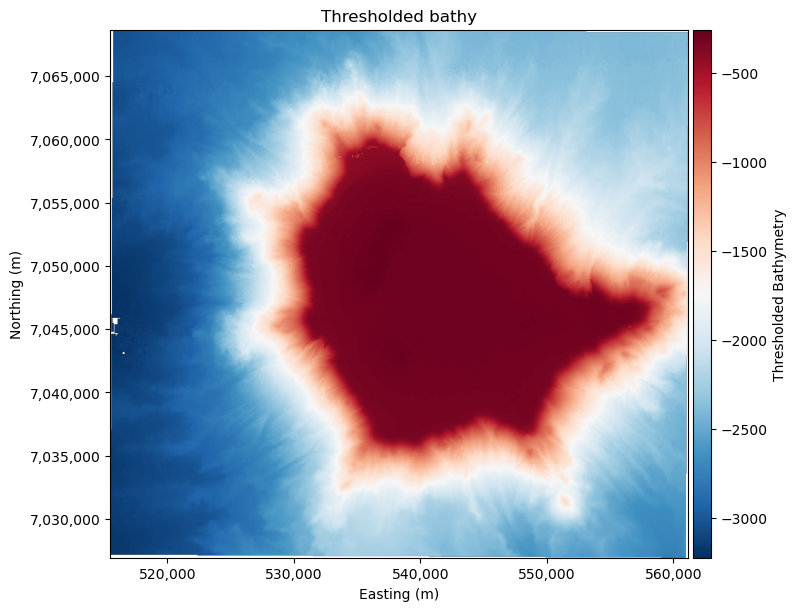

In [7]:
# TPI Visualization
# -----------------
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

im = ax.imshow(
    tpi,
    extent=extent,
    origin="upper",
    cmap="RdBu_r",
)

ax.set_title("Thresholded bathy")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Thresholded Bathymetry")

plt.show()

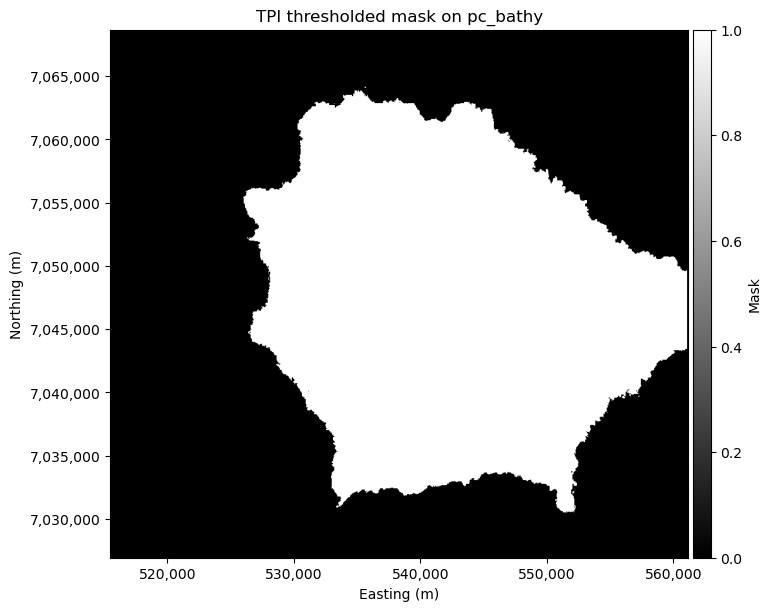

In [13]:
# Threshold Visualization
# -----------------------
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

im = ax.imshow(
    mask_high.astype(float),
    extent=extent,
    origin="upper",
    cmap="gray",
    vmin=0,
    vmax=1,
)

ax.set_title("TPI thresholded mask on pc_bathy")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Mask")

plt.show()

In [9]:
# Polygonization
# --------------
shapes_all = rfeatures.shapes(mask_high.astype(np.uint8), transform=transform)
geoms_all = [shape(geom) for geom, val in shapes_all if val == 1]

gdf_all = gpd.GeoDataFrame(geometry=geoms_all, crs=crs)

print("Polygons before filtering:", len(gdf_all))

Polygons before filtering: 22


In [10]:
def hillshade(
    bathy,
    transform,
    z_factor=1.0,
    azimuth_deg=315.0,
    altitude_deg=45.0,
    invert_bathy=False,
):
    # Pixel sizes. This also works for rotated affine transforms.
    dx = np.hypot(transform.a, transform.d)
    dy = np.hypot(transform.b, transform.e)

    if dx == 0 or dy == 0:
        raise ValueError("Invalid transform: pixel size cannot be zero.")

    surface = bathy.astype(float)

    if invert_bathy:
        surface = -surface

    surface = surface * z_factor

    dz_dy, dz_dx = np.gradient(surface, dy, dx)

    slope = np.arctan(np.hypot(dz_dx, dz_dy))
    aspect = np.arctan2(dz_dy, -dz_dx)

    az = np.deg2rad(360.0 - azimuth_deg + 90.0)
    alt = np.deg2rad(altitude_deg)

    shade = (
        np.sin(alt) * np.cos(slope)
        + np.cos(alt) * np.sin(slope) * np.cos(az - aspect)
    )

    hs = 255.0 * np.clip(shade, 0.0, 1.0)

    hs[np.isnan(bathy)] = np.nan

    return hs

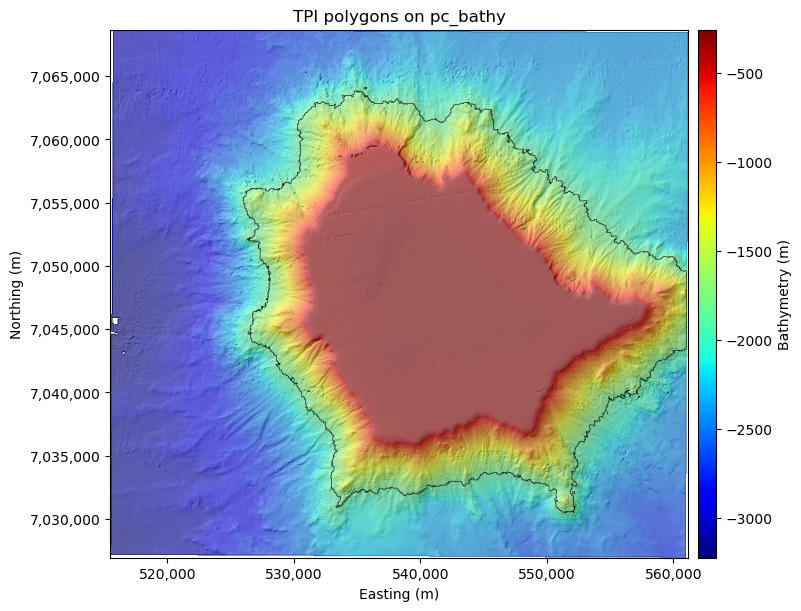

In [11]:
#%% Polygon Visualization
# -----------------------
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

im = ax.imshow(bathy,extent=extent,origin="upper",cmap="jet")

hs = hillshade(bathy,transform)

ax.imshow(
    hs,
    extent=extent,
    origin="upper",
    cmap="gray",
    alpha=0.5,
)

if len(gdf_all):
    gdf_all.boundary.plot(ax=ax, color="black", linewidth=0.5, alpha=0.8)

ax.set_title("TPI polygons on pc_bathy")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Bathymetry (m)")

plt.show()

In [12]:
# Area Filtering
area_threshold = 45.0 # square meters

gdf_high = gdf_all.copy()

if len(gdf_high):
    gdf_high["area"] = gdf_high.area
    gdf_high = gdf_high[gdf_high["area"] > area_threshold].copy()

print("Polygons after filtering:", len(gdf_high))

Polygons after filtering: 22
